# PI-DeepONet for the Lorig Random-Barrier Model

**Reference:** Lorig, M. (2024). *Structural Default with a Random Barrier*.

## General setup (Lorig §1)

Let $X = (X_t)_{t \geq 0}$ be a Markov diffusion with dynamics

$$dX_t = \mu(X_t)\,dt + \sigma(X_t)\,dW_t,$$

and let $\bar{X}_t := \max_{s \in [0,t]} X_s$ be its running maximum. Let $Z > X_0$ be a random variable independent of $X$ with distribution $F_Z$. The default time is $\tau := \inf\{t \geq 0 : X_t = Z\}$.

Lorig defines the general quantity

$$u(x, \bar{x}) := E\!\left(e^{-\int_0^\tau \gamma(X_s)\,ds}\,\phi(\tau, X_\tau)\;\Big|\; X_0 = x,\; Z > \bar{x}\right),$$

for functions $\gamma : S \to \mathbb{R}_+$ and $\phi : \mathbb{R}_+ \times S \to \mathbb{R}$.

## Example: Brownian Motion with Drift (Lorig §2)

We then look at

$$\mu(x) = \mu > 0, \quad \sigma(x) = \sigma > 0, \quad \gamma(x) = 0, \quad \phi(t, x) = \mathbf{1}_{\{t > T\}},$$

so $dX_t = \mu\,dt + \sigma\,dW_t$ and

$$u(x, \bar{x}) = E\!\left(\mathbf{1}_{\{\tau > T\}}\;\Big|\; X_0 = x,\; Z > \bar{x}\right) = P(\tau > T \mid X_0 = x,\; Z > \bar{x}).$$

The credit spread equals the bond yield:

$$Y(x, \bar{x};\, T) = -\frac{1}{T}\log u(x, \bar{x}).$$

**Our approach:** Lorig computes $u$ via Fourier transform. Here we solve for the fixed-barrier survival probability $w(x, T, z) := P(\tau_z > T \mid X_0 = x)$ using a PI-DeepONet, then recover $u$ by integrating over $F_Z$.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.analytical import lorig_fpt_density, analytical_survival
from src.models import PIDeepONet, deeponet_survival
from src.training import train_pideeponet
from src.credit import exponential_f_Z_cond, compute_u_and_spread
from src.style import setup_publication_style

setup_publication_style()
torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## 1. Parameters and analytical baseline (Lorig §2)

For the BM-with-drift case Lorig sets $\mu(x) = \mu > 0$, $\sigma(x) = \sigma > 0$. The fixed-barrier first-passage time density is given in in the *Handbook of Brownian Motion* (p. 295):

$$P(\tau_z \in ds \mid X_0 = x) = \frac{z - x}{s\sqrt{2\pi\sigma^2 s}}\exp\!\left(-\frac{(z - x - \mu s)^2}{2\sigma^2 s}\right)ds, \qquad x < z.$$

The fixed-barrier survival probability follows by integration:

$$w(x, T, z) := P(\tau_z > T \mid X_0 = x) = 1 - \int_0^T \frac{z-x}{s\sqrt{2\pi\sigma^2 s}}\exp\!\left(-\frac{(z-x-\mu s)^2}{2\sigma^2 s}\right)ds.$$

In [2]:
mu    = 0.05
sigma = 0.2
x_min = -1.5
x0    = 0.0
T_max = 2.0
z_min, z_max = 0.5, 1.5

## 2. PI-DeepONet architecture

We learn the operator $z \mapsto w(\cdot,\cdot;\,z)$ where $w(x, T, z)$ is the fixed-barrier survival probability defined in §1.

- **Branch net:** $z \to b(z) \in \mathbb{R}^p$
- **Trunk net:** $(\xi, t) \to \varphi(\xi, t) \in \mathbb{R}^p$, where $\xi = (x - x_{\min})/(z - x_{\min}) \in [0,1]$ is a normalised coordinate
- **Output:** $w = \sigma\!\left(\langle b(z),\,\varphi(\xi,t)\rangle + b_0\right) \in (0,1)$

The sigmoid keeps outputs in $(0,1)$, consistent with $w$ being a probability. Bias $b_0$ is initialised to 3.0 so the network starts near $w = 1$, matching the initial condition $w(x, 0, z) = 1$. IC and BC are enforced via weighted soft losses (see §3).

In [3]:
model = PIDeepONet(x_min=x_min, p=80, branch_hidden=(80, 80, 80), trunk_hidden=(80, 80, 80)).to(device)
print(model)

PIDeepONet(
  (branch): MLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=80, bias=True)
      (1): Tanh()
      (2): Linear(in_features=80, out_features=80, bias=True)
      (3): Tanh()
      (4): Linear(in_features=80, out_features=80, bias=True)
      (5): Tanh()
      (6): Linear(in_features=80, out_features=80, bias=True)
    )
  )
  (trunk): MLP(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=80, bias=True)
      (1): Tanh()
      (2): Linear(in_features=80, out_features=80, bias=True)
      (3): Tanh()
      (4): Linear(in_features=80, out_features=80, bias=True)
      (5): Tanh()
      (6): Linear(in_features=80, out_features=80, bias=True)
    )
  )
)


## 3. Training

The fixed-barrier survival probability $w(x, T, z) = P(\tau_z > T \mid X_0 = x)$ satisfies the Feynman-Kac PDE (applying the Markov generator to $w$ with $\gamma = 0$):

$$\partial_T w + \mu\,\partial_x w + \frac{\sigma^2}{2}\partial_{xx} w = 0, \qquad w(x, 0, z) = 1, \quad w(z, T, z) = 0.$$

This PDE is not written by Lorig (he works in Fourier space), but follows directly from Feynman-Kac applied to his setup.

**Normalised coordinate.** Setting $\xi = (x - x_{\min})/L$ with $L = z - x_{\min}$, the PDE becomes

$$\partial_T w + \frac{\mu}{L}\,\partial_\xi w + \frac{\sigma^2}{2L^2}\,\partial_{\xi\xi} w = 0.$$

**Three soft losses:** PDE residual, IC $w(\xi, 0; z) = 1$ (sampled on $\xi \in [0, 0.95]$), BC $w(1, T; z) = 0$.

In [4]:
history = train_pideeponet(
    model, mu=mu, sigma=sigma, x_min=x_min, T_max=T_max, z_min=z_min, z_max=z_max,
    n_epochs=15000, lr=1e-3,
    n_pde=4096, n_ic=1024, n_bc=1024,
    lambda_ic=50.0, lambda_bc=50.0,
    device=device, log_every=500,
)

epoch     0  pde 6.496e-05  ic 3.202e-03  bc 8.585e-01  total 4.309e+01
epoch   500  pde 1.087e-01  ic 5.425e-04  bc 9.545e-04  total 1.836e-01
epoch  1000  pde 1.283e-01  ic 7.089e-04  bc 5.425e-04  total 1.909e-01
epoch  1500  pde 1.182e-01  ic 3.608e-04  bc 6.146e-04  total 1.670e-01
epoch  2000  pde 1.126e-01  ic 4.385e-04  bc 4.634e-04  total 1.577e-01
epoch  2500  pde 9.688e-02  ic 5.164e-04  bc 3.171e-04  total 1.386e-01
epoch  3000  pde 9.682e-02  ic 2.843e-04  bc 2.910e-04  total 1.256e-01
epoch  3500  pde 1.107e-01  ic 3.574e-04  bc 3.709e-04  total 1.471e-01
epoch  4000  pde 9.870e-02  ic 1.751e-04  bc 7.291e-04  total 1.439e-01
epoch  4500  pde 9.645e-02  ic 3.088e-04  bc 5.375e-04  total 1.388e-01
epoch  5000  pde 9.064e-02  ic 3.623e-04  bc 3.937e-04  total 1.284e-01
epoch  5500  pde 1.025e-01  ic 1.757e-04  bc 5.755e-04  total 1.401e-01
epoch  6000  pde 1.162e-01  ic 5.078e-04  bc 3.273e-04  total 1.580e-01
epoch  6500  pde 9.819e-02  ic 6.973e-04  bc 2.301e-04  total 1.

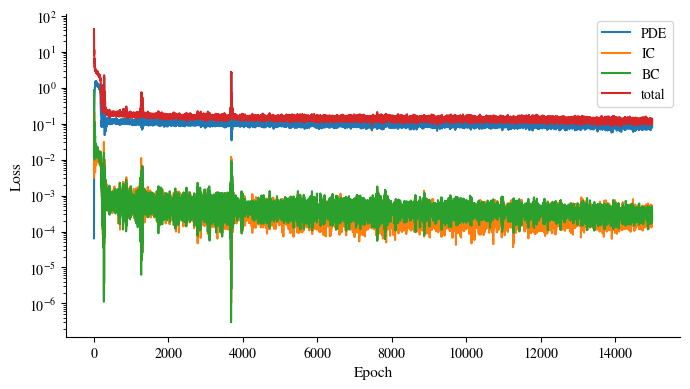

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.semilogy(history['pde'],   label='PDE')
ax.semilogy(history['ic'],    label='IC')
ax.semilogy(history['bc'],    label='BC')
ax.semilogy(history['total'], label='total')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Compare to analytical for fixed $z$

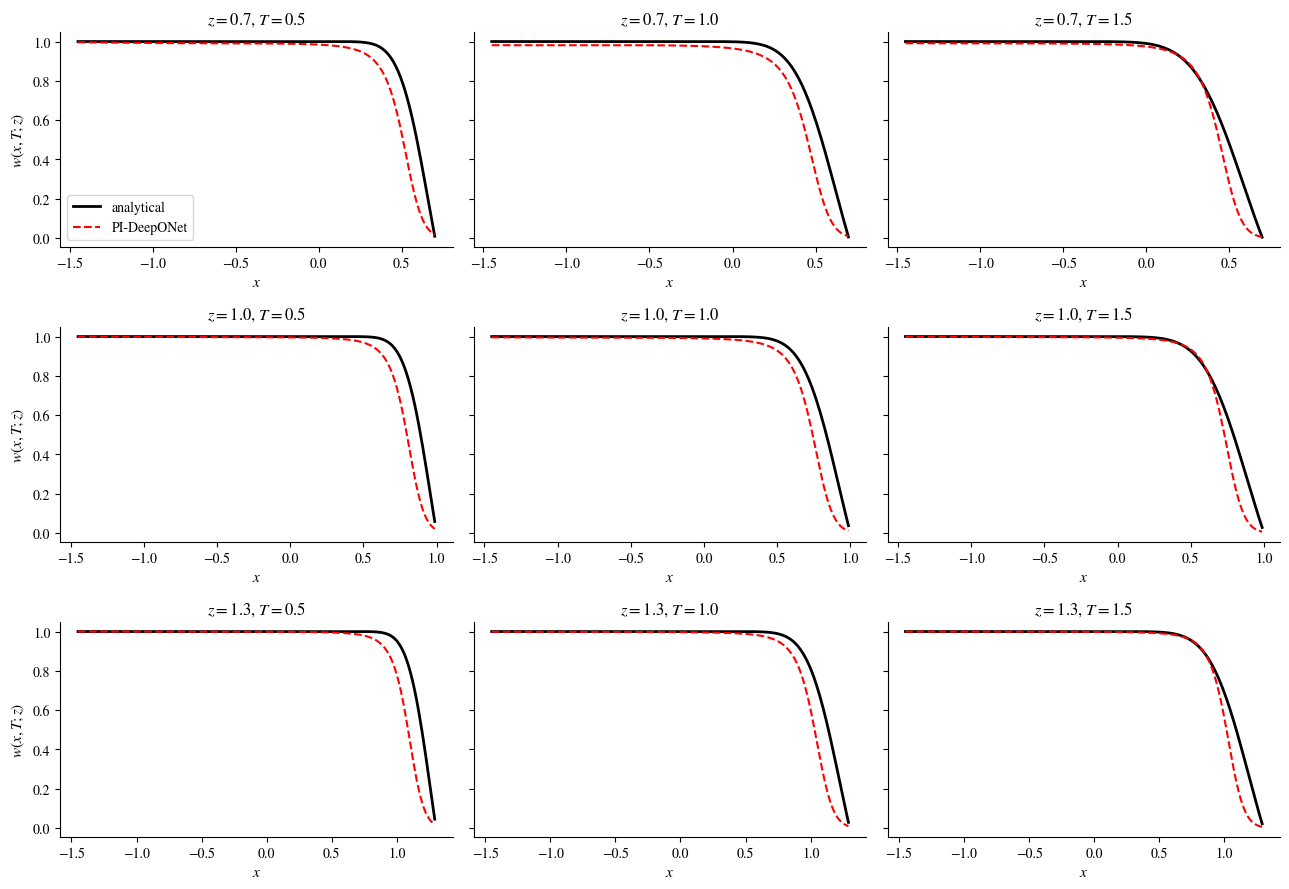

In [6]:
# Plot at three barrier levels
z_show = [0.7, 1.0, 1.3]
T_show = [0.5, 1.0, 1.5]
x_grid = np.linspace(x_min + 0.05, max(z_show) - 0.01, 200)

fig, axes = plt.subplots(len(z_show), len(T_show), figsize=(13, 9), sharey=True)
for i, z_val in enumerate(z_show):
    x_local = x_grid[x_grid < z_val - 1e-3]
    for j, T_val in enumerate(T_show):
        w_ana = analytical_survival(x_local, T_val, z_val, mu, sigma)
        w_pinn = deeponet_survival(model, x_local, T_val, z_val, device=device)
        ax = axes[i, j]
        ax.plot(x_local, w_ana,  'k-',  label='analytical', lw=2)
        ax.plot(x_local, w_pinn, 'r--', label='PI-DeepONet', lw=1.5)
        ax.set_title(f'$z={z_val}$, $T={T_val}$')
        ax.set_xlabel('$x$')
        if j == 0: ax.set_ylabel('$w(x, T; z)$')
        if i == 0 and j == 0: ax.legend()
plt.tight_layout(); plt.show()

## 5. Credit spread (Lorig §2)

We recover $u(x, \bar{x})$ by averaging $w$ over the conditional distribution of $Z$ given $Z > \bar{x}$:

$$u(x, \bar{x}) = \int_{\bar{x}}^\infty w(x, T, z)\,F_{Z \mid Z > \bar{x}}(dz).$$

For $Z \sim \mathrm{Exp}(\eta)$, 

$$F_{Z \mid Z > \bar{x}}(dz) = \eta\,e^{-\eta(z - \bar{x})}\,\mathbf{1}_{z \geq \bar{x}}\,dz.$$

With $r = 0$, the credit spread is:

$$Y(x, \bar{x};\, T) = -\frac{1}{T}\log u(x, \bar{x}).$$

We set $\bar{x} = X_0 = 0$ (no prior path, so $\bar{x} = x_0$) and $\eta = 2$.

In [7]:
eta   = 2.0  # Lorig's example: Z ~ Exp(eta)
x_bar = 0.0  # bar{x} = X_0 (no prior path observed)
x_val = 0.0  # X_0

z_grid   = np.linspace(max(x_bar, z_min) + 1e-3, z_max, 80)
f_Z_cond = exponential_f_Z_cond(z_grid, x_bar, eta)
T_grid   = np.linspace(0.1, T_max, 25)

u_ana,  Y_ana  = compute_u_and_spread(
    lambda x, T, z: analytical_survival(np.array([x]), np.array([T]), z, mu, sigma)[0],
    T_grid, x_val, z_grid, f_Z_cond)
u_pinn, Y_pinn = compute_u_and_spread(
    lambda x, T, z: deeponet_survival(model, np.array([x]), np.array([T]), z, device=device)[0],
    T_grid, x_val, z_grid, f_Z_cond)

rel_err = np.abs(Y_pinn - Y_ana) / np.maximum(np.abs(Y_ana), 1e-12)
print(f'Spread mean rel err: {rel_err.mean():.3%}')
print(f'Spread max  rel err: {rel_err.max():.3%}')

Spread mean rel err: 1.375%
Spread max  rel err: 2.660%


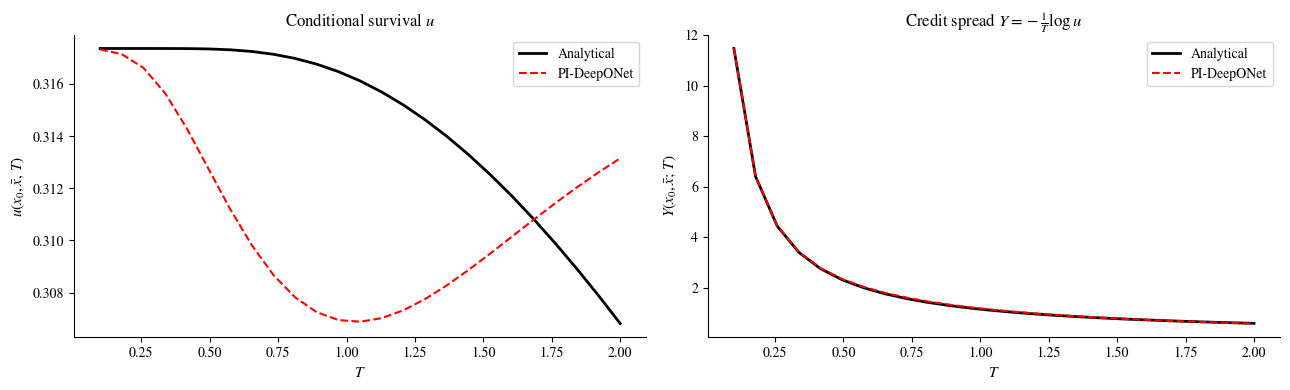

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(T_grid, u_ana,  'k-',  label='Analytical', lw=2)
axes[0].plot(T_grid, u_pinn, 'r--', label='PI-DeepONet', lw=1.5)
axes[0].set_xlabel('$T$'); axes[0].set_ylabel('$u(x_0, \\bar{x},\\, T)$'); axes[0].legend()
axes[0].set_title('Conditional survival $u$')

axes[1].plot(T_grid, Y_ana,  'k-',  label='Analytical', lw=2)
axes[1].plot(T_grid, Y_pinn, 'r--', label='PI-DeepONet', lw=1.5)
axes[1].set_xlabel('$T$'); axes[1].set_ylabel('$Y(x_0, \\bar{x};\\, T)$'); axes[1].legend()
axes[1].set_title('Credit spread $Y = -\\frac{1}{T}\\log u$')
plt.tight_layout(); plt.show()